In [113]:
import pandas as pd
import matplotlib.pyplot as plt

In [114]:
data = pd.read_csv("parsed_save2.csv")

In [115]:
data.head()

,Unnamed: 0,hero_r1,hero_r2,stage_pre,stage_flop,stage_turn,stage_river,board_r1,board_r2,board_r3,board_r4,board_r5,suit_po,stra_po,gut_po,position_norm,facing_ratio,if_fold,hero_bet_ratio,result
0,0,0.357,0.5,1,0,0,0,0.0,0.000,0.000,0.000,0.000,0.2,0.2,0,0.167,0.667,0,1.333,0.175
1,1,0.357,0.5,0,1,0,0,0.5,0.286,0.429,0.000,0.000,0.4,0.8,0,0.167,0.000,0,0.571,0.175
2,2,0.357,0.5,0,0,1,0,0.5,0.286,0.429,0.929,0.000,0.4,0.8,0,0.167,0.000,0,0.000,0.175
3,3,0.357,0.5,0,0,1,0,0.5,0.286,0.429,0.929,0.000,0.4,0.8,0,0.167,0.400,0,0.400,0.175
4,4,0.357,0.5,0,0,0,1,0.5,0.286,0.429,0.929,0.786,0.4,0.8,0,0.167,0.000,0,0.514,0.175


In [116]:
data.columns

Index(['Unnamed: 0', 'hero_r1', 'hero_r2', 'stage_pre', 'stage_flop',
       'stage_turn', 'stage_river', 'board_r1', 'board_r2', 'board_r3',
       'board_r4', 'board_r5', 'suit_po', 'stra_po', 'gut_po', 'position_norm',
       'facing_ratio', 'if_fold', 'hero_bet_ratio', 'result'],
      dtype='str')

In [117]:
temp = data[data["stage_pre"] == 1]
temp.loc[temp["facing_ratio"] <= temp["hero_bet_ratio"]]

,Unnamed: 0,hero_r1,hero_r2,stage_pre,stage_flop,stage_turn,stage_river,board_r1,board_r2,board_r3,board_r4,board_r5,suit_po,stra_po,gut_po,position_norm,facing_ratio,if_fold,hero_bet_ratio,result
0,0,0.357,0.500,1,0,0,0,0.0,0.0,0.0,0.0,0.0,0.2,0.2,0,0.167,0.667,0,1.333,0.175
9,9,0.429,0.500,1,0,0,0,0.0,0.0,0.0,0.0,0.0,0.4,0.4,0,0.500,0.667,0,0.667,-0.020
12,12,0.571,0.500,1,0,0,0,0.0,0.0,0.0,0.0,0.0,0.4,0.4,0,0.833,0.833,0,0.833,0.085
14,14,0.357,0.571,1,0,0,0,0.0,0.0,0.0,0.0,0.0,0.2,0.2,0,0.000,0.667,0,1.333,-0.020
18,18,0.714,1.000,1,0,0,0,0.0,0.0,0.0,0.0,0.0,0.2,0.2,0,0.500,0.667,0,1.333,0.110
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1252,1252,0.786,1.000,1,0,0,0,0.0,0.0,0.0,0.0,0.0,0.4,0.2,0,0.000,0.667,0,1.333,0.275
1262,1262,1.000,0.500,1,0,0,0,0.0,0.0,0.0,0.0,0.0,0.2,0.2,0,0.667,0.667,0,0.667,-0.020
1264,1264,1.000,0.786,1,0,0,0,0.0,0.0,0.0,0.0,0.0,0.4,0.2,0,0.833,0.667,0,1.333,0.045
1275,1275,0.857,0.714,1,0,0,0,0.0,0.0,0.0,0.0,0.0,0.2,0.2,0,0.833,0.667,0,1.333,-0.190


In [118]:
temp.loc[temp["if_fold"] == 1, "action"] = "fold"
temp.loc[(temp["if_fold"] == 0) & (temp["hero_bet_ratio"] == 0), "action"] = "check"
temp.loc[(temp["facing_ratio"] < temp["hero_bet_ratio"]) & (temp["action"] != 0) & (temp["action"] != 1), "action"] = "raise"
temp.fillna({"action": "call"}, inplace=True)
temp["action"].value_counts()

action
fold     355
raise    176
call     159
check     17
Name: count, dtype: int64

In [119]:
temp.drop(columns=["Unnamed: 0","if_fold", "result"], inplace=True)


In [120]:
temp.columns

Index(['hero_r1', 'hero_r2', 'stage_pre', 'stage_flop', 'stage_turn',
       'stage_river', 'board_r1', 'board_r2', 'board_r3', 'board_r4',
       'board_r5', 'suit_po', 'stra_po', 'gut_po', 'position_norm',
       'facing_ratio', 'hero_bet_ratio', 'action'],
      dtype='str')

In [121]:
from zlib import crc32
import numpy as np

def is_id_in_test_set(identifier, test_ratio):
    return crc32(np.int64(identifier)) < test_ratio * 2**32

def split_data_with_id_hash(data, test_ratio, id_column):
    ids = data[id_column]
    in_test_set = ids.apply(lambda id: is_id_in_test_set(id, test_ratio))
    return data.loc[~in_test_set], data.loc[in_test_set]

In [122]:
temp_with_id = temp.reset_index()
temp_with_id.columns
train_set, test_set = split_data_with_id_hash(temp_with_id, test_ratio=0.2, id_column="index")

In [123]:
train_set.columns

Index(['index', 'hero_r1', 'hero_r2', 'stage_pre', 'stage_flop', 'stage_turn',
       'stage_river', 'board_r1', 'board_r2', 'board_r3', 'board_r4',
       'board_r5', 'suit_po', 'stra_po', 'gut_po', 'position_norm',
       'facing_ratio', 'hero_bet_ratio', 'action'],
      dtype='str')

In [124]:
label = train_set["action"]
train_set.drop(columns=["action"], inplace=True)

In [126]:
ACTION_TO_ID = {
    "fold": 0,
    "check": 1,
    "call": 2,
    "bet": 3,
    "raise": 4,
}

label_encoded = label.map(ACTION_TO_ID)

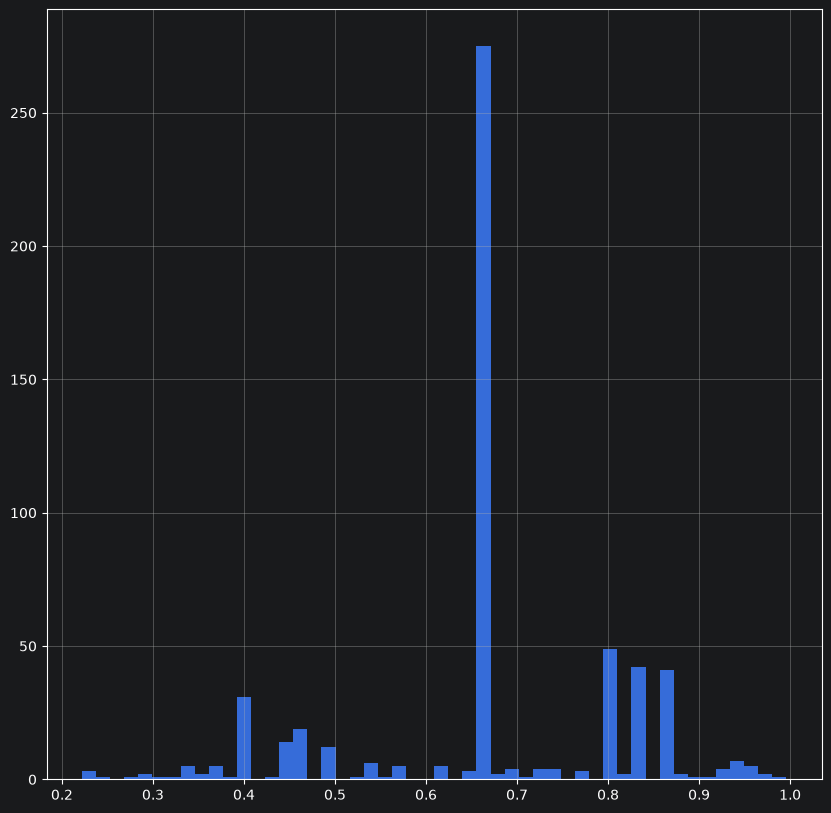

In [130]:
train_set["facing_ratio"].hist(bins=50, figsize=(10,10), xlabelsize=10, ylabelsize=10)
plt.show()